# Chunking analysis

Distributions behind the chunking parameters in `configs/pipeline.yaml`
(child = 256 tokens / 32 overlap, parent ≤ 1024 tokens, `cl100k_base` counting).

Two questions this notebook answers:

1. **Do token budgets behave the same across languages?** Character-based
   budgets would not: the tokenizer fragments Polish and Ukrainian far more
   than English, so the same character count carries different token costs per
   language.
2. **Do the chosen budgets fit the corpus structure?** Most legal units
   (articles/recitals) should fit a single parent, and children should rarely
   be degenerate fragments.

In [1]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

chunks = json.loads(Path("../data/processed/chunks.json").read_text())
children = [c for c in chunks if c["chunk_type"] == "child"]
parents = [c for c in chunks if c["chunk_type"] == "parent"]
print(f"{len(parents)} parents, {len(children)} children")
Counter(c["language"] for c in children)

1986 parents, 3710 children


Counter({'pl': 2012, 'en': 1553, 'uk': 145})

## Characters per token, by language

Why `length_function` must be a tokenizer and not `len()`: the same 256-token
budget corresponds to very different character counts per language.

In [2]:
ratios = defaultdict(list)
for c in children:
    ratios[c["language"]].append(len(c["text"]) / c["token_count"])
for lang, r in sorted(ratios.items()):
    print(f"{lang}: {sum(r)/len(r):.2f} chars/token (n={len(r)})")

en: 5.14 chars/token (n=1553)
pl: 2.71 chars/token (n=2012)
uk: 1.72 chars/token (n=145)


## Child chunk token distribution per language

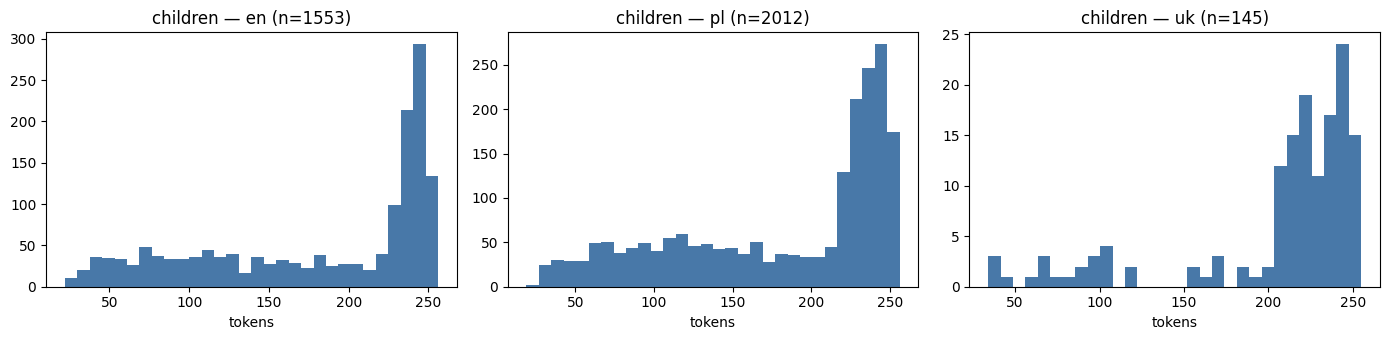

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)
for ax, lang in zip(axes, ["en", "pl", "uk"]):
    counts = [c["token_count"] for c in children if c["language"] == lang]
    ax.hist(counts, bins=30, color="#4878a8")
    ax.set_title(f"children — {lang} (n={len(counts)})")
    ax.set_xlabel("tokens")
plt.tight_layout()

## Parent chunk sizes and how many units split

Parents tile each structural unit. Units that fit the 1024-token budget stay
whole — important because a statute article is the natural citation target.

units split into >1 parent: 93 of 1732 (5.4%)


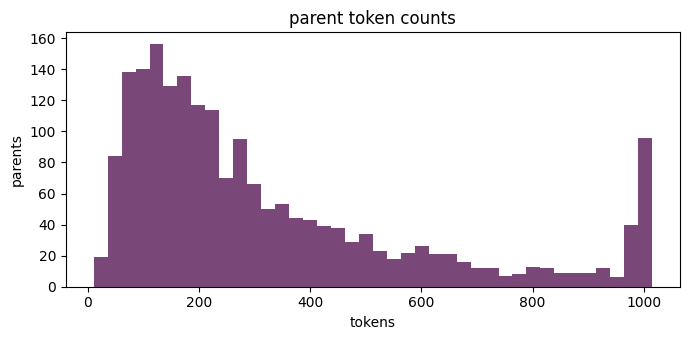

In [4]:
parent_counts = [p["token_count"] for p in parents]
plt.figure(figsize=(7, 3.5))
plt.hist(parent_counts, bins=40, color="#7a4878")
plt.xlabel("tokens"); plt.ylabel("parents"); plt.title("parent token counts")
plt.tight_layout()

unit_parents = Counter(p["parent_id"].rsplit(":p", 1)[0] if ":p" in p["parent_id"] else p["parent_id"] for p in parents)
split_units = sum(1 for n in unit_parents.values() if n > 1)
print(f"units split into >1 parent: {split_units} of {len(unit_parents)} "
      f"({100*split_units/len(unit_parents):.1f}%)")

## Chunks per document

In [5]:
rows = defaultdict(lambda: [0, 0])
for c in chunks:
    rows[c["source_id"]][0 if c["chunk_type"] == "parent" else 1] += 1
print(f"{'source_id':28} {'parents':>8} {'children':>9}")
for sid, (p, ch) in sorted(rows.items()):
    print(f"{sid:28} {p:8} {ch:9}")

source_id                     parents  children
dsa_en                            258       458
edpb_opinion_28_2024_pl           135       196
eu_ai_act_2024                    327       667
gdpr_en                           276       428
gdpr_pl                           304       675
pl_data_protection_act            180       277
pl_labour_code                    446       776
ua_data_protection_law             42       145
uodo_ai_report_2024                18        88


## Conclusions

- **256-token children** keep retrieval granularity fine enough that a single
  child rarely spans more than one legal thought (a paragraph or two), while
  staying well above degenerate-fragment size; the 50-char floor removes
  splitter tails.
- **1024-token parents** keep the vast majority of articles and recitals whole
  (see split percentage above) — the LLM almost always receives a complete
  article as context, which is what a correct legal citation needs.
- **Token-based budgets are non-negotiable for a multilingual corpus**: with
  `cl100k_base`, English legal text averages ~4 chars/token while Ukrainian
  averages ~2 — a character-based splitter would produce Ukrainian chunks with
  half the semantic content of English ones at the same nominal size.
- **32-token overlap (12.5%)** preserves sentence continuity across child
  boundaries without materially inflating the index.